# Temp_cat Classification — TEMPURA (Phase 3)

**計画書:** [`../docs/classification_plan_ja.md`](../docs/classification_plan_ja.md)

本ノートは、原核生物 8,639 株の **温度カテゴリ `temp_cat`**
（Psychrophile / Mesophile / Thermophile / Hyperthermophile）を
`Tmin` / `Tmax` / GC 含量 / 分類情報から予測する分類モデルを学習・比較する。

1. **特徴量エンジニアリング**: `log_Genome_size`、`GC_diff`、`Tmean` を追加
2. **5-fold StratifiedKFold** + **GridSearchCV** でハイパーパラメータ調整
3. **Random Forest** vs **XGBoost** を比較
4. **Accuracy / Precision / Recall / F1** を報告
5. **混同行列**を両モデルで可視化
6. **最終モデルの特徴量重要度 Top 10** を表示

## 1. セットアップ

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

import xgboost as xgb

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid')
RNG = 42
print(f'xgboost {xgb.__version__}')

xgboost 3.2.0


## 2. データ読み込み + 派生列（特徴量エンジニアリング）

- `temp_cat` は EDA と同じ 4 カテゴリ。
- `phylum_grouped` は出現率 ≥ 1 % の門だけ残し、それ以外は `Other`。
- **新規特徴量**: `log_Genome_size`、`GC_diff`、`Tmean`

In [2]:
df = pd.read_csv('../data/raw/tempura.csv')

def temp_category(t):
    if t < 20:  return 'Psychrophile'
    if t < 45:  return 'Mesophile'
    if t < 80:  return 'Thermophile'
    return 'Hyperthermophile'
df['temp_cat'] = df['Topt_ave'].apply(temp_category)

# 門の集約
phylum_counts = df['phylum'].value_counts(normalize=True)
top_phyla = phylum_counts[phylum_counts >= 0.01].index.tolist()
df['phylum_grouped'] = np.where(df['phylum'].isin(top_phyla), df['phylum'], 'Other')
df['phylum_grouped'] = df['phylum_grouped'].fillna('Unknown')

# --- 新規特徴量 ---
df['log_Genome_size'] = np.log1p(df['Genome_size'])     # 歪んだ分布を対数正規化
df['GC_diff']         = df['Genome_GC'] - df['16S_GC']  # GC 差分
df['Tmean']           = (df['Tmin'] + df['Tmax']) / 2   # 温度範囲の中心

print(f"Rows : {len(df):,}")
print(f"Kept phyla (≥1%): {len(top_phyla)}")
print()
print("temp_cat distribution:")
print(df['temp_cat'].value_counts())
print()
print("New features summary:")
print(df[['log_Genome_size', 'GC_diff', 'Tmean']].describe().round(3))

Rows : 8,639
Kept phyla (≥1%): 5

temp_cat distribution:
temp_cat
Mesophile           7576
Thermophile          732
Psychrophile         206
Hyperthermophile     125
Name: count, dtype: int64

New features summary:
       log_Genome_size   GC_diff     Tmean
count         1061.000  8237.000  8639.000
mean             1.527    -1.519    28.829
std              0.359    11.640    11.380
min              0.588   -34.400     1.500
25%              1.281   -11.900    22.500
50%              1.548     0.000    26.500
75%              1.775     9.000    31.000
max              2.639    20.100   103.500


## 3. 特徴量 / 目的変数の定義

In [3]:
NUMERIC_FEATURES = [
    'Tmin', 'Tmax', 'Tmax_Tmin', 'Tmean',
    '16S_GC', 'Genome_GC', 'GC_diff',
    'log_Genome_size',
]
CATEGORICAL_FEATURES = ['superkingdom', 'phylum_grouped']

X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES].copy()

# ラベルエンコード（0=Psychro, 1=Meso, 2=Thermo, 3=Hyper の順に固定）
CLASS_ORDER = ['Psychrophile', 'Mesophile', 'Thermophile', 'Hyperthermophile']
le = LabelEncoder()
le.fit(CLASS_ORDER)
y = le.transform(df['temp_cat'])
class_names = list(le.classes_)

print('X shape :', X.shape)
print('y shape :', y.shape)
print('classes :', class_names)
print('class counts:', np.bincount(y))

X shape : (8639, 10)
y shape : (8639,)
classes : ['Hyperthermophile', 'Mesophile', 'Psychrophile', 'Thermophile']
class counts: [ 125 7576  206  732]


## 4. 前処理パイプライン

- 数値: median 補完 → 標準化
- カテゴリ: Unknown 補完 → One-Hot

In [4]:
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])
preprocess = ColumnTransformer([
    ('num', numeric_pipe, NUMERIC_FEATURES),
    ('cat', categorical_pipe, CATEGORICAL_FEATURES),
])
preprocess

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Tmin', 'Tmax', 'Tmax_Tmin', 'Tmean',
                                  '16S_GC', 'Genome_GC', 'GC_diff',
                                  'log_Genome_size']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='Unknown',
                                                                strategy='constant')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['superkingdom', 'phylum_grouped'])])

## 5. CV 定義（temp_cat で層化）

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)
for i, (tr, va) in enumerate(cv.split(X, y), 1):
    dist = pd.Series(y[va]).value_counts().sort_index()
    print(f'fold {i} valid: ' + ', '.join(f'{class_names[k]}={v}' for k, v in dist.items()))

fold 1 valid: Hyperthermophile=25, Mesophile=1515, Psychrophile=41, Thermophile=147
fold 2 valid: Hyperthermophile=25, Mesophile=1515, Psychrophile=41, Thermophile=147
fold 3 valid: Hyperthermophile=25, Mesophile=1516, Psychrophile=41, Thermophile=146
fold 4 valid: Hyperthermophile=25, Mesophile=1515, Psychrophile=42, Thermophile=146
fold 5 valid: Hyperthermophile=25, Mesophile=1515, Psychrophile=41, Thermophile=146


## 6. ベースライン（Dummy Classifier）

常に多数派（Mesophile）を予測するモデル。Accuracy は高く、macro F1 はほぼゼロ
になるはず。クラス不均衡の典型症状を確認する。

In [6]:
dummy = Pipeline([
    ('preprocess', preprocess),
    ('model', DummyClassifier(strategy='most_frequent', random_state=RNG)),
])
y_pred_dummy = cross_val_predict(dummy, X, y, cv=cv, n_jobs=-1)

def score_row(name, y_true, y_pred):
    return {
        'model':        name,
        'accuracy':     accuracy_score(y_true, y_pred),
        'precision_w':  precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'recall_w':     recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'f1_w':         f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'precision_m':  precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_m':     recall_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_m':         f1_score(y_true, y_pred, average='macro', zero_division=0),
    }

rows = [score_row('Dummy (most_frequent)', y, y_pred_dummy)]
pd.DataFrame(rows).round(3)

,model,accuracy,precision_w,recall_w,f1_w,precision_m,recall_m,f1_m
0,Dummy (most_frequent),0.877,0.769,0.877,0.819,0.219,0.25,0.234


## 7. Random Forest — GridSearchCV

`class_weight='balanced'` で不均衡対応。`refit` 基準は **macro F1**（少数派重視）。

In [7]:
rf_pipe = Pipeline([
    ('preprocess', preprocess),
    ('model', RandomForestClassifier(class_weight='balanced', random_state=RNG, n_jobs=-1)),
])
rf_grid = {
    'model__n_estimators':     [200, 400],
    'model__max_depth':        [6, 12, None],
    'model__min_samples_leaf': [1, 3],
}
rf_search = GridSearchCV(
    rf_pipe, rf_grid,
    scoring='f1_macro',
    cv=cv, n_jobs=-1, verbose=0, refit=True,
)
rf_search.fit(X, y)

print('Best RF params    :', rf_search.best_params_)
print(f'Best RF CV macro-F1: {rf_search.best_score_:.4f}')

Best RF params    : {'model__max_depth': None, 'model__min_samples_leaf': 3, 'model__n_estimators': 400}
Best RF CV macro-F1: 0.8584


In [8]:
# ベストモデルで CV 予測を取得して指標計算
y_pred_rf = cross_val_predict(rf_search.best_estimator_, X, y, cv=cv, n_jobs=-1)
rows.append(score_row('RandomForest (tuned)', y, y_pred_rf))
pd.DataFrame(rows).round(3)

,model,accuracy,precision_w,recall_w,f1_w,precision_m,recall_m,f1_m
0,Dummy (most_frequent),0.877,0.769,0.877,0.819,0.219,0.250,0.234
1,RandomForest (tuned),0.961,0.965,0.961,0.963,0.827,0.896,0.858


## 8. XGBoost — GridSearchCV

`sample_weight` で不均衡を反映させる。

In [9]:
# クラスごとの重みを算出（sample_weight）
class_counts = np.bincount(y)
sample_weight = np.array([len(y) / (len(class_counts) * class_counts[c]) for c in y])

xgb_pipe = Pipeline([
    ('preprocess', preprocess),
    ('model', xgb.XGBClassifier(
        objective='multi:softprob',
        num_class=len(class_names),
        tree_method='hist',
        random_state=RNG,
        n_jobs=-1,
        eval_metric='mlogloss',
    )),
])
xgb_grid = {
    'model__n_estimators':  [200, 400],
    'model__max_depth':     [4, 6, 8],
    'model__learning_rate': [0.05, 0.1],
}
xgb_search = GridSearchCV(
    xgb_pipe, xgb_grid,
    scoring='f1_macro',
    cv=cv, n_jobs=-1, verbose=0, refit=True,
)
xgb_search.fit(X, y, model__sample_weight=sample_weight)

print('Best XGB params    :', xgb_search.best_params_)
print(f'Best XGB CV macro-F1: {xgb_search.best_score_:.4f}')

Best XGB params    : {'model__learning_rate': 0.1, 'model__max_depth': 6, 'model__n_estimators': 400}
Best XGB CV macro-F1: 0.8491


In [10]:
y_pred_xgb = cross_val_predict(
    xgb_search.best_estimator_, X, y, cv=cv, n_jobs=-1,
    fit_params={'model__sample_weight': sample_weight},
)
rows.append(score_row('XGBoost (tuned)', y, y_pred_xgb))
pd.DataFrame(rows).round(3)

,model,accuracy,precision_w,recall_w,f1_w,precision_m,recall_m,f1_m
0,Dummy (most_frequent),0.877,0.769,0.877,0.819,0.219,0.250,0.234
1,RandomForest (tuned),0.961,0.965,0.961,0.963,0.827,0.896,0.858
2,XGBoost (tuned),0.960,0.962,0.960,0.961,0.830,0.871,0.849


## 9. モデル比較サマリ

In [11]:
summary = pd.DataFrame(rows).round(3)
summary

,model,accuracy,precision_w,recall_w,f1_w,precision_m,recall_m,f1_m
0,Dummy (most_frequent),0.877,0.769,0.877,0.819,0.219,0.250,0.234
1,RandomForest (tuned),0.961,0.965,0.961,0.963,0.827,0.896,0.858
2,XGBoost (tuned),0.960,0.962,0.960,0.961,0.830,0.871,0.849


In [12]:
# 各モデルのクラス別 classification_report
print('\n=== Random Forest (tuned) ===')
print(classification_report(y, y_pred_rf, target_names=class_names, digits=3))

print('\n=== XGBoost (tuned) ===')
print(classification_report(y, y_pred_xgb, target_names=class_names, digits=3))


=== Random Forest (tuned) ===
                  precision    recall  f1-score   support

Hyperthermophile      0.903     0.968     0.934       125
       Mesophile      0.986     0.972     0.979      7576
    Psychrophile      0.542     0.728     0.621       206
     Thermophile      0.879     0.915     0.897       732

        accuracy                          0.961      8639
       macro avg      0.827     0.896     0.858      8639
    weighted avg      0.965     0.961     0.963      8639


=== XGBoost (tuned) ===
                  precision    recall  f1-score   support

Hyperthermophile      0.917     0.968     0.942       125
       Mesophile      0.982     0.974     0.978      7576
    Psychrophile      0.539     0.636     0.584       206
     Thermophile      0.882     0.906     0.894       732

        accuracy                          0.960      8639
       macro avg      0.830     0.871     0.849      8639
    weighted avg      0.962     0.960     0.961      8639



## 10. 混同行列

両モデルを横並びで可視化。

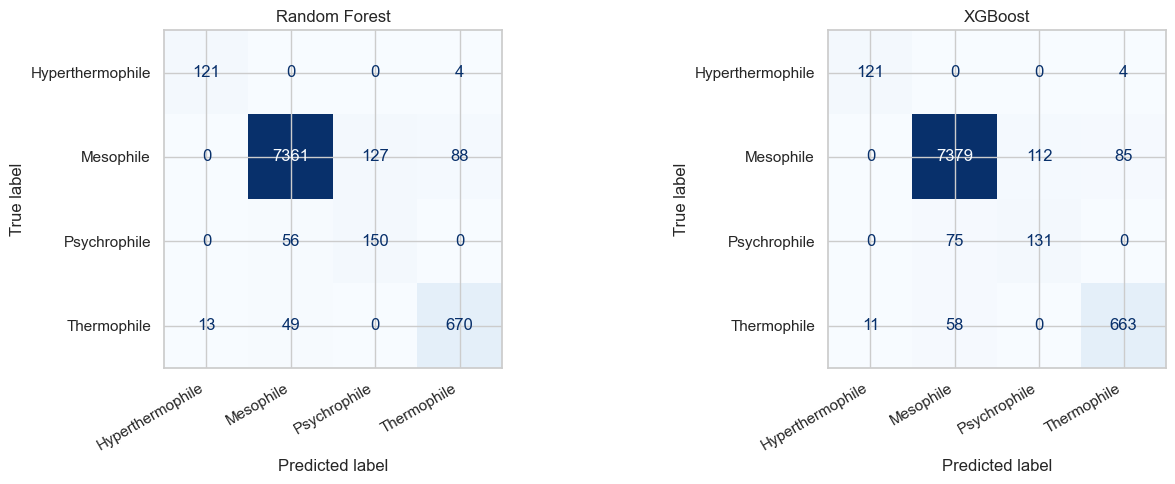

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, title, y_pred in [
    (axes[0], 'Random Forest', y_pred_rf),
    (axes[1], 'XGBoost',       y_pred_xgb),
]:
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='d')
    ax.set_title(title)
    ax.set_xticklabels(class_names, rotation=30, ha='right')

plt.tight_layout()
plt.show()

## 11. 最終モデル選定と特徴量重要度 Top 10

macro F1（CV）で優れた方を最終モデルとする。

In [14]:
rf_f1  = rf_search.best_score_
xgb_f1 = xgb_search.best_score_
print(f'RF  macro-F1 (CV): {rf_f1:.4f}')
print(f'XGB macro-F1 (CV): {xgb_f1:.4f}')

if xgb_f1 >= rf_f1:
    best_name, best_pipe = 'XGBoost', xgb_search.best_estimator_
else:
    best_name, best_pipe = 'RandomForest', rf_search.best_estimator_
print(f'\n=> 最終モデル: {best_name}')

RF  macro-F1 (CV): 0.8584
XGB macro-F1 (CV): 0.8491

=> 最終モデル: RandomForest


In [15]:
# 前処理後の特徴量名を復元
preprocess_fitted = best_pipe.named_steps['preprocess']
num_names = NUMERIC_FEATURES
cat_enc = preprocess_fitted.named_transformers_['cat']['onehot']
cat_names = cat_enc.get_feature_names_out(CATEGORICAL_FEATURES).tolist()
feat_names = num_names + cat_names

# 特徴量重要度（どちらのモデルでも feature_importances_ が使える）
importances = best_pipe.named_steps['model'].feature_importances_
imp_df = (pd.DataFrame({'feature': feat_names, 'importance': importances})
            .sort_values('importance', ascending=False)
            .reset_index(drop=True))
print(f'=== {best_name}: Top 10 feature importances ===')
imp_df.head(10)

=== RandomForest: Top 10 feature importances ===


,feature,importance
0,Tmax,0.298301
1,Tmean,0.275655
2,Tmin,0.154467
3,16S_GC,0.102077
4,superkingdom_Bacteria,0.035794
5,GC_diff,0.027541
6,superkingdom_Archaea,0.025611
7,Genome_GC,0.024113
8,Tmax_Tmin,0.020441
9,log_Genome_size,0.011687


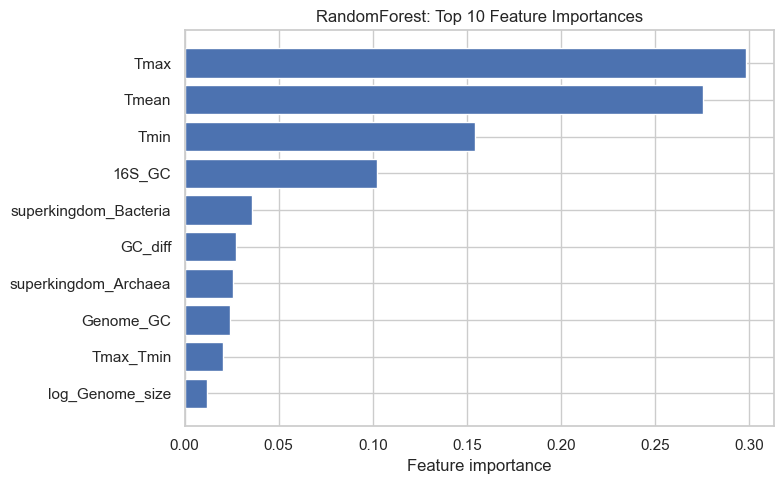

In [16]:
# 可視化
top = imp_df.head(10).iloc[::-1]  # 上から大きい順に見せるため逆順
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top['feature'], top['importance'], color='#4c72b0')
ax.set_xlabel('Feature importance')
ax.set_title(f'{best_name}: Top 10 Feature Importances')
plt.tight_layout()
plt.show()

## 12. 計画書目標との突合

| 指標 | 目標 | 判定 |
|---|---|---|
| Weighted F1 ≥ 0.95 | TBD | §9 の結果を参照 |
| Macro F1 ≥ 0.75 | TBD |  |
| Hyperthermophile F1 ≥ 0.80 | TBD | §9 の classification_report |
| Hyperthermophile Recall ≥ 0.85 | TBD |  |

→ 結果は `docs/classification_results_ja.md` に清書する。

## 13. 最終モデルの保存

In [17]:
import os, joblib
os.makedirs('../models', exist_ok=True)
path = f'../models/temp_cat_classifier_{best_name.lower()}.joblib'
joblib.dump(best_pipe, path)
print('saved:', path)

saved: ../models/temp_cat_classifier_randomforest.joblib
